# Principal Component Analysis (PCA)

## What Is PCA?

PCA answers the question: "In what directions does this data vary the most?"  
It finds a new coordinate system, the **principal components**, aligned with the directions of maximum variance. Projecting data onto the top $k$ components discards the least informative dimensions while retaining the most structure.

Mathematically, PCA finds the eigenvectors of the data covariance matrix:

$$\mathbf{C} = \frac{1}{n-1}\mathbf{X}^T\mathbf{X}, \qquad \mathbf{C}\mathbf{v}_k = \lambda_k \mathbf{v}_k$$

The eigenvector $\mathbf{v}_1$ with the largest eigenvalue $\lambda_1$ points in the direction of greatest variance; this is **PC1**. $\mathbf{v}_2$ is the next orthogonal direction of greatest remaining variance, **PC2**, and so on.

## 1. Setup & Data Export

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, sys

sys.path.insert(0, os.path.abspath('../../../src'))
from mlpackage.unsupervised_learning.pca import PCA
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

CSV_PATH = 'wine.csv'
if not os.path.exists(CSV_PATH):
    wine = load_wine()
    df_out = pd.DataFrame(wine.data, columns=wine.feature_names)
    df_out['target'] = wine.target
    df_out.to_csv(CSV_PATH, index=False)
    print('Dataset exported.')
else:
    print('Dataset already present.')

Dataset already present.


## 2. Data Exploration — The Correlation Problem

Shape: (178, 14)
Classes: [0 1 2]


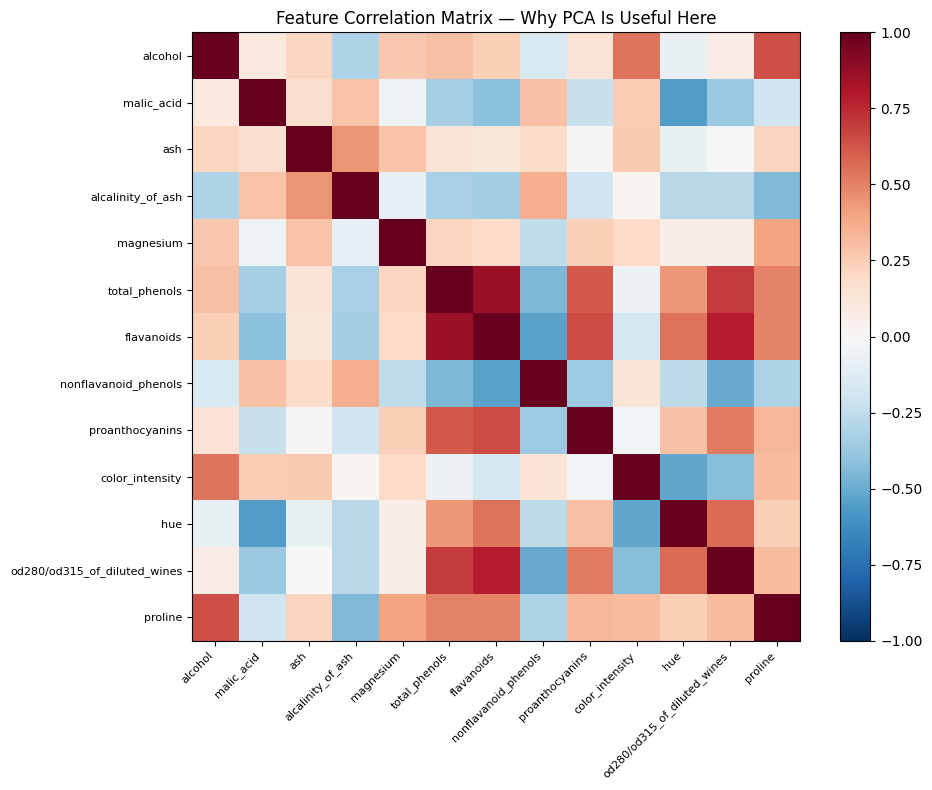

In [2]:
df = pd.read_csv(CSV_PATH)
feature_cols = [c for c in df.columns if c != 'target']

print('Shape:', df.shape)
print('Classes:', np.unique(df['target'].values))

fig, ax = plt.subplots(figsize=(10, 8))
corr_matrix = df[feature_cols].corr()
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
ax.set_xticklabels(feature_cols, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(feature_cols, fontsize=8)
ax.set_title('Feature Correlation Matrix — Why PCA Is Useful Here', fontsize=12)
plt.tight_layout()
plt.show()

Each cell in the matrix above shows the Pearson correlation between two features.
- Red (close to +1) = strong positive correlation.
- Blue (close to -1) = strong negative correlation.
- White (near 0) = no linear relationship.

Many feature pairs are strongly correlated. For example, 'total_phenols' and 'flavanoids' both reflect grape polyphenol content and tend to move together. This redundancy means the 13 features do not contain 13 independent dimensions of information.

PCA exploits this redundancy: correlated features collapse into a single principal component, letting us represent the data accurately in far fewer dimensions.

## 3. Preprocessing

PCA is sensitive to feature scale. `proline` ranges up to 1680 while `nonflavanoid_phenols` is in [0.1, 0.7]. Without StandardScaler, proline would dominate the first principal component simply due to its large variance (nothing to do with its actual importance).

In [3]:
X = df[feature_cols].values
y = df['target'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'X shape: {X_scaled.shape}')
print(f'Mean (should be ~0): {X_scaled.mean(axis=0).round(2)}')
print(f'Std  (should be ~1): {X_scaled.std(axis=0).round(2)}')

X shape: (178, 13)
Mean (should be ~0): [-0. -0. -0. -0. -0.  0. -0.  0. -0.  0.  0.  0. -0.]
Std  (should be ~1): [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 4. Explained Variance — How Many Components Do We Need?

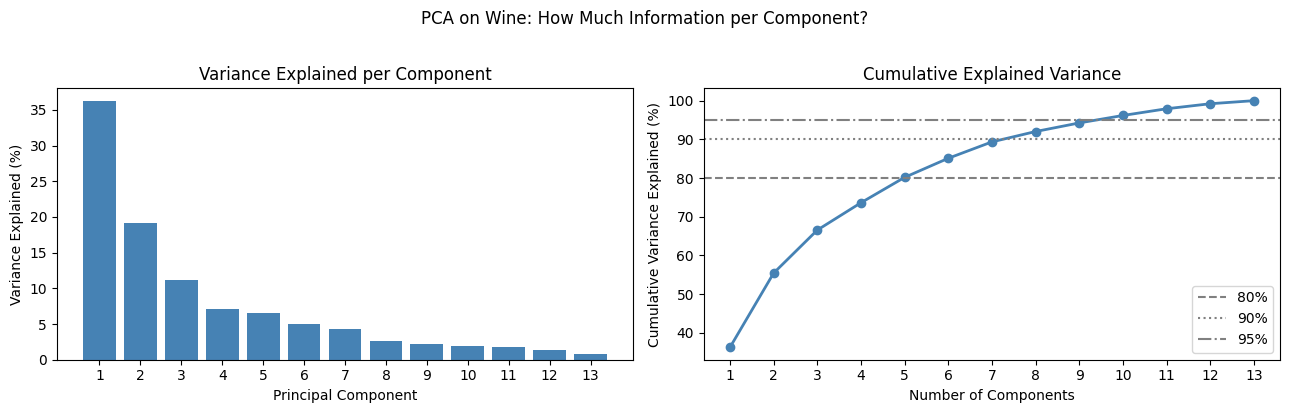

5 components explain >= 80% of variance
10 components explain >= 95% of variance


In [4]:
pca_full = PCA(n_components=13)
pca_full.fit(X_scaled)

evr = pca_full.explained_variance_ratio_
cumulative_evr = np.cumsum(evr)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, 14), evr * 100, color='steelblue')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')
axes[0].set_title('Variance Explained per Component')
axes[0].set_xticks(range(1, 14))

axes[1].plot(range(1, 14), cumulative_evr * 100, 'o-',
             color='steelblue', linewidth=2)
for threshold, ls in [(0.80,'--'),(0.90,':'),(0.95,'-.')]: 
    axes[1].axhline(threshold * 100, color='gray', linestyle=ls,
                    label=f'{int(threshold*100)}%')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance Explained (%)')
axes[1].set_title('Cumulative Explained Variance')
axes[1].set_xticks(range(1, 14))
axes[1].legend()

plt.suptitle('PCA on Wine: How Much Information per Component?', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

for k, threshold in [(k, 0.80) for k in range(1,14)]:
    if cumulative_evr[k-1] >= 0.80:
        print(f'{k} components explain >= 80% of variance')
        break
for k in range(1,14):
    if cumulative_evr[k-1] >= 0.95:
        print(f'{k} components explain >= 95% of variance')
        break

The left plot shows the individual variance per component.   
PC1 explains the largest fraction of variance while each subsequent component explains progressively less.  
The rapid drop-off shows that most variance is concentrated in the first few components, quantifying the redundancy we saw in the correlation matrix.

The plot on the right shows the cumulative variance.  
The horizontal lines mark common thresholds (80%, 90%, 95%).  
The x-axis at each threshold shows how many components are needed. For the wine dataset, typically 3–5 components capture 80%+ of the variance.

## 5. 2D Projection — Visualizing 13 Dimensions

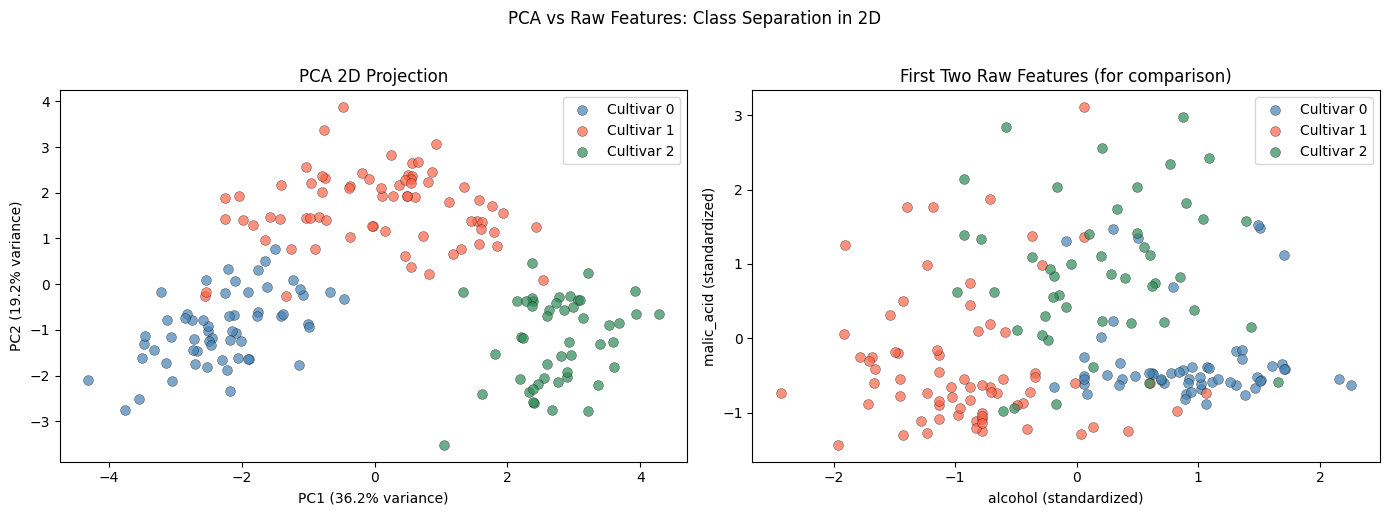

Total variance in 2D PCA: 55.4%


In [5]:
pca_2d = PCA(n_components=2)
pca_2d.fit(X_scaled)
X_2d = pca_2d.transform(X_scaled)

colors = ['steelblue', 'tomato', 'seagreen']
class_names = ['Cultivar 0', 'Cultivar 1', 'Cultivar 2']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PCA projection
for i, (name, color) in enumerate(zip(class_names, colors)):
    mask = y == i
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    label=name, color=color, alpha=0.7, s=50, edgecolors='k', lw=0.3)
axes[0].set_xlabel(f'PC1 ({evr[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({evr[1]*100:.1f}% variance)')
axes[0].set_title('PCA 2D Projection')
axes[0].legend()

# First two raw features for comparison
for i, (name, color) in enumerate(zip(class_names, colors)):
    mask = y == i
    axes[1].scatter(X_scaled[mask, 0], X_scaled[mask, 1],
                    label=name, color=color, alpha=0.7, s=50, edgecolors='k', lw=0.3)
axes[1].set_xlabel(f'{feature_cols[0]} (standardized)')
axes[1].set_ylabel(f'{feature_cols[1]} (standardized)')
axes[1].set_title('First Two Raw Features (for comparison)')
axes[1].legend()

plt.suptitle('PCA vs Raw Features: Class Separation in 2D', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'Total variance in 2D PCA: {(evr[0]+evr[1])*100:.1f}%')

The left plot shows the PCA projection. Each point is a wine sample projected onto the two most informative axes. The three cultivars form distinct, well-separated clusters, even though PCA was computed without any class labels.  
This confirms that the chemical structure of the wines genuinely differs between cultivars, and that PCA found an axis system that respects it.

The plot on the right shows the raw features. Plotting alcohol vs malic acid gives a much messier separation. These two features alone do not capture the cultivar structure. 

Sinve PCA is an unsupervised method, it knew nothing about the cultivar labels when finding the components. The clean separation in the left panel shows that the chemical variation that matters most in the data happens to also separate the classes.

## 6. PCA Loadings — What Does Each Component Represent?

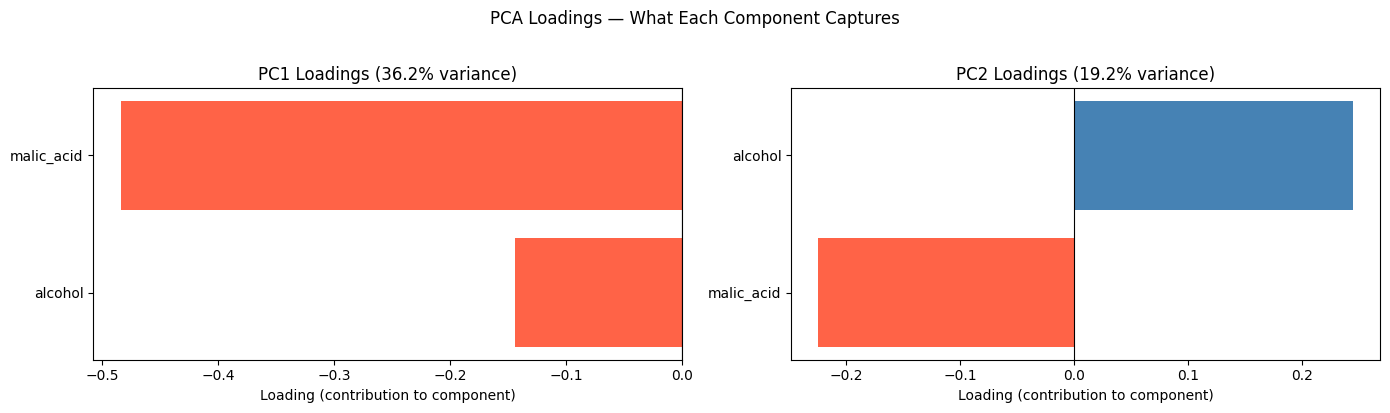

In [6]:
components = pca_2d.components_   # shape: (2, 13)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, comp_idx in zip(axes, [0, 1]):
    loadings = components[comp_idx]
    order = np.argsort(np.abs(loadings))
    bar_colors = ['tomato' if l < 0 else 'steelblue' for l in loadings[order]]
    ax.barh([feature_cols[i] for i in order], loadings[order], color=bar_colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_xlabel('Loading (contribution to component)')
    ax.set_title(f'PC{comp_idx+1} Loadings ({evr[comp_idx]*100:.1f}% variance)')

plt.suptitle('PCA Loadings — What Each Component Captures', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

In the plots above, each bar shows a feature’s contribution to a principal component. Blue represents a positive contribution and red, negative.

- PC1 (36.2% variance): dominated by negative loadings from *malic_acid* and *alcohol*.  A high PC1 score indicates wine that is lower in alcohol and acidity relative to average.

- PC2 (19.2% variance): positive loading for *alcohol*, negative for *malic_acid*. This captures the contrast between high alcohol and low acidity.

## 7. Reconstruction Error

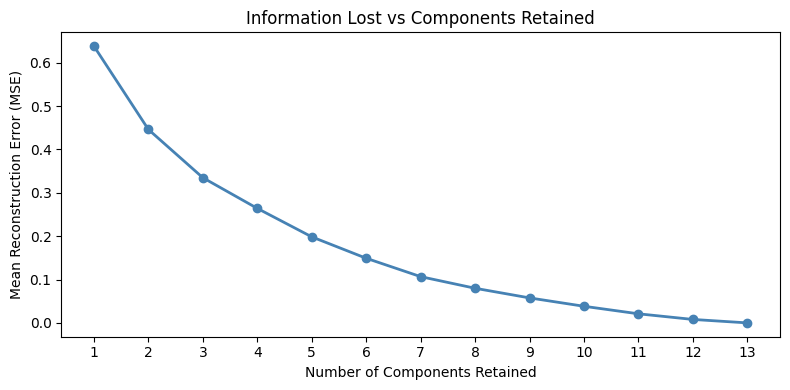

In [7]:
n_components_list = range(1, 14)
reconstruction_errors = []

for k in n_components_list:
    pca_k = PCA(n_components=k)
    pca_k.fit(X_scaled)
    X_reconstructed = pca_k.inverse_transform(pca_k.transform(X_scaled))
    mse = np.mean((X_scaled - X_reconstructed) ** 2)
    reconstruction_errors.append(mse)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(list(n_components_list), reconstruction_errors, 'o-',
        color='steelblue', linewidth=2)
ax.set_xlabel('Number of Components Retained')
ax.set_ylabel('Mean Reconstruction Error (MSE)')
ax.set_title('Information Lost vs Components Retained')
ax.set_xticks(list(n_components_list))
plt.tight_layout()
plt.show()

- X-axis: how many principal components we keep.
- Y-axis: how much information is lost (average squared reconstruction error).

At k=13 (all components), reconstruction error = 0, i.e. we keep everything.  
At k=1, most information is discarded.

The curve drops steeply in the first few components (where most of the variance lives) then flattens, which is consistent with the explained variance plot.

In practice, choose k at the 'elbow' of this curve: the point where adding one more component gives diminishing reconstruction improvement. This is the same concept as the elbow method in K-Means.

## 8. Key Takeaways

- The **correlation matrix** motivates PCA: when 13 features are heavily correlated, the true information content is much lower than 13 dimensions suggest. PCA quantifies and exploits this.
- The **explained variance plot** answers the key question: how many components capture enough information? For wine, typically 3–5 components suffice for 90%+ retention.
- The **2D scatter plot** demonstrates that PCA can separate classes without ever seeing the labels. The chemical variation structure of the wine already encodes cultivar identity.
- **Loadings** give chemical meaning to the abstract PC axes, confirming that the first component captures wine quality/phenolic richness.
- **Reconstruction error** is the direct cost of dimensionality reduction: lower k saves compute and memory but loses information. The choice of k always involves this trade-off.

## Why PCA?

- **13 highly correlated features**: many chemical measurements (e.g., alcohol, flavanoids, total phenols) co-vary strongly. PCA should find that a large fraction of variance lives in just 2–3 components, revealing that 13 features carry substantial redundancy.
- **3 well-separated classes**: projecting to 2D should visually separate the three wine cultivars, demonstrating that PCA-compressed features still contain discriminative structure.
- **Purely numerical, no missing values**: all preprocessing effort goes into understanding the algorithm rather than data cleaning.
- **Interesting loadings**: the principal components correspond to interpretable chemical axes (e.g., "overall quality" or "acidity profile"), making the data readable from the PCA loadings.